# MK Praktikum Unggulan Universitas Gunadarma
# Mata Kuliah: Praktikum Teknologi Kecerdasan Artifisial (Tingkat 1)

---

# Pertemuan VIII

## Pengenalan Image Processing dengan Python

### 1. Import library yang diperlukan

Bagian ini memuat beberapa library wajib yang digunakan dalam notebook ini, antara lain:


*   [Numpy](https://www.numpy.org/) adalah library untuk manipulasi array, digunakan untuk aljabar linier, transformasi Fourier, dan kemampuan bilangan acak.
*   [Pandas](https://pandas.pydata.org/) adalah library untuk manipulasi data dan analisis data.
*   [CV2](https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_gui/py_image_display/py_image_display.html)  adalah library untuk tugas-tugas computer vision.
*   [Skimage](https://scikit-image.org/) adalah library yang mendukung aplikasi pengolah gambar pada python.
*   [Matplotlib](https://matplotlib.org/) adalah library yang menghasilkan gambar dan menyediakan toolkit antarmuka pengguna grafis.


In [1]:
import numpy as np
import pandas as pd
import cv2 as cv
from skimage import io
from PIL import Image
import matplotlib.pylab as plt

### 2. Baca Gambar dari URL
Pada langkah ini kita akan membaca gambar dari url, dan menampilkannya menggunakan openCV, perhatikan perbedaannya saat membaca gambar dalam format RGB dan BGR. Saluran warna input default dalam format BGR untuk openCV.

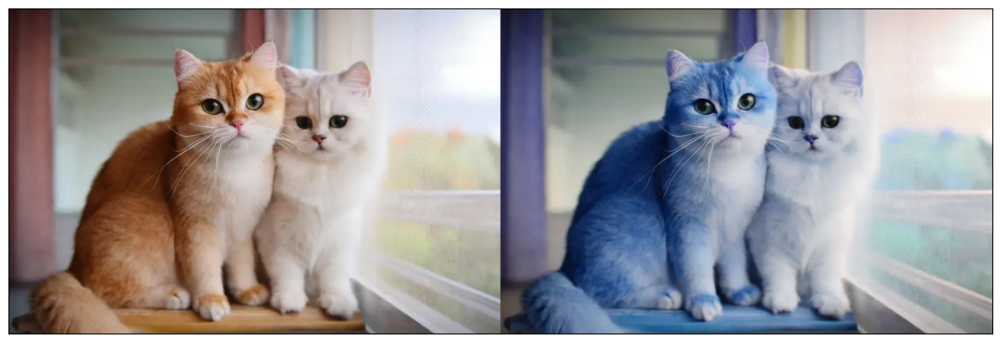

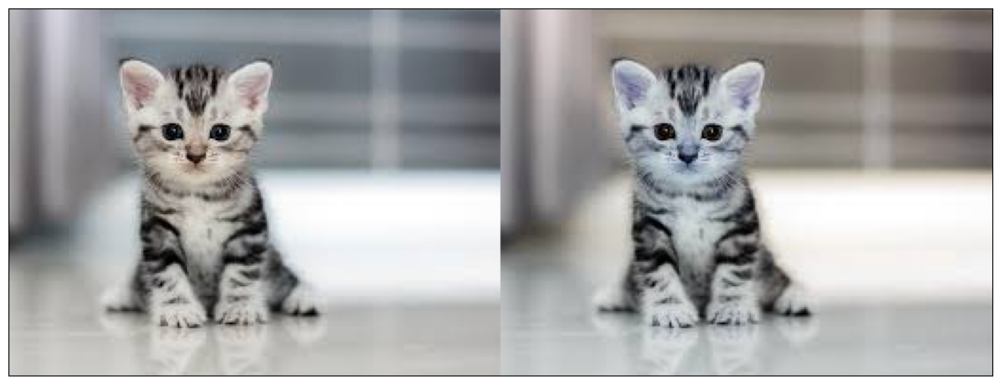

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


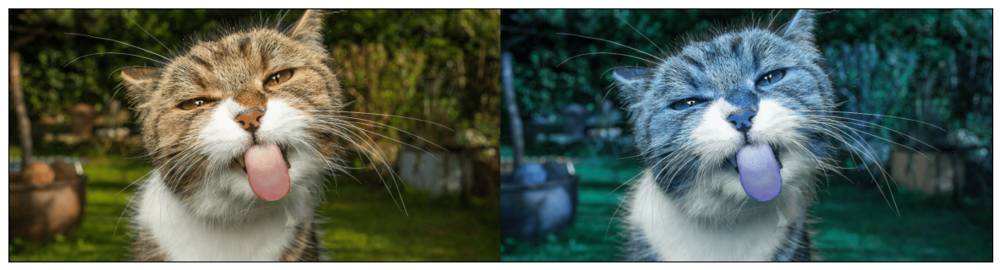

In [2]:
# Buat daftar untuk menyimpan url gambar
urls = ["https://d1bpj0tv6vfxyp.cloudfront.net/articles/253564_20-5-2021_13-2-0.webp",
        "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQnhjqftdBJNowWegrpvYUstljjSwZ-w7qq9A&s",
        "https://images.tokopedia.net/img/KRMmCm/2023/8/29/360dbc5b-92c5-4e07-919f-7338969b4447.png"
        ]

# Fungsi untuk Baca dan tampilkan gambar
def cv_imshow(img):
    plt.figure(figsize = (15,15))
    plt.imshow(img)
    plt.xticks([]), plt.yticks([])
    plt.show()

# loop terhadap URL gambar, Anda dapat menyimpan beberapa url gambar dalam daftar

for url in urls:
    image = io.imread(url)
    image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    final_frame = cv.hconcat((image, image_2))
    cv_imshow(final_frame)

---
### **TUGAS 1: BACA GAMBAR DARI URL DAN TAMPILKAN**
Cari gambar dari google, lalu gunakan url address dari gambar tersebut untuk melakukan operasi di bawah ini dengan menghapus tanda komentarnya (`#`).

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


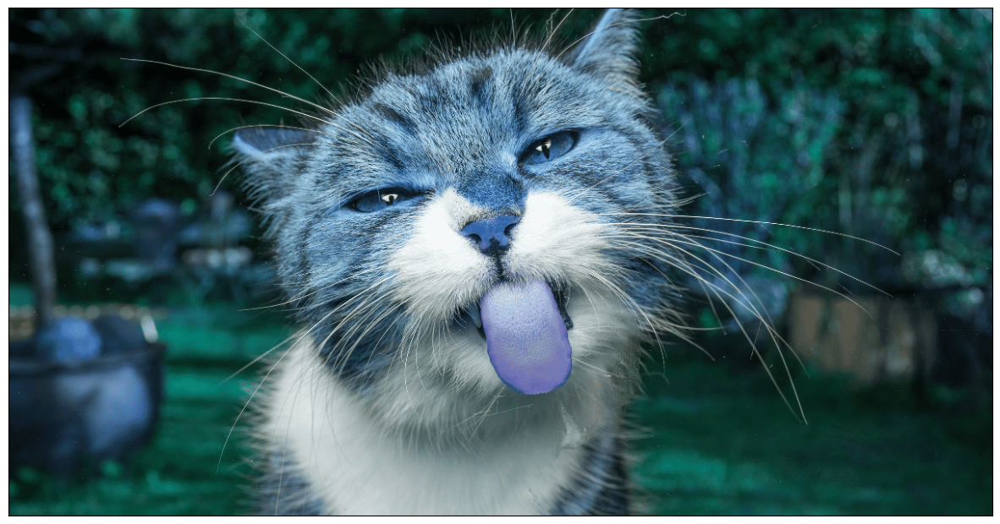

In [3]:
## TODO 1: LOAD IMAGE FROM URL

url = "https://images.tokopedia.net/img/KRMmCm/2023/8/29/360dbc5b-92c5-4e07-919f-7338969b4447.png"
myImg = io.imread(url)
cv_imshow(cv.cvtColor(myImg, cv.COLOR_BGR2RGB))

---
### 3. Kontur Gambar dan Histogram



In [4]:
# Gunakan image dari indeks pertama (Langkah #2) dalam variabel urls
image = io.imread(urls[0])

### Menghasilkan Histogram Citra Berwarna dan Citra Grayscale
Terkadang Anda ingin meningkatkan kontras pada gambar atau memperluas kontras di wilayah tertentu sambil mengorbankan detail dalam warna yang tidak terlalu bervariasi, atau tidak penting. Alat yang baik untuk menemukan wilayah yang menarik adalah histogram. Untuk membuat histogram dari data gambar kita, kita menggunakan fungsi `matplot.pylab hist()`.

Menampilkan histogram dari semua piksel pada gambar berwarna:

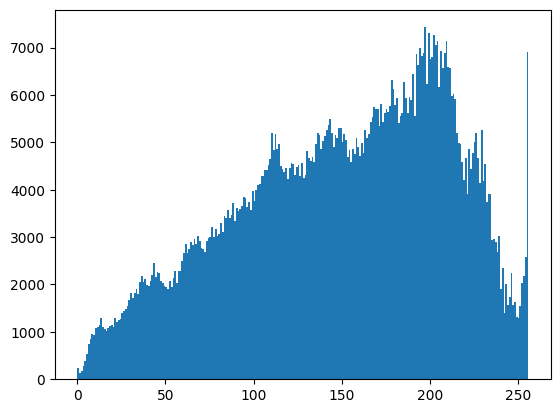

In [5]:
plt.hist(image.ravel(),bins = 256, range = [0,256])
plt.show()

Menampilkan histogram saluran R, G, B kita dapat mengamati bahwa saluran hijau memiliki banyak piksel di 255, yang mewakili tambalan putih pada gambar.

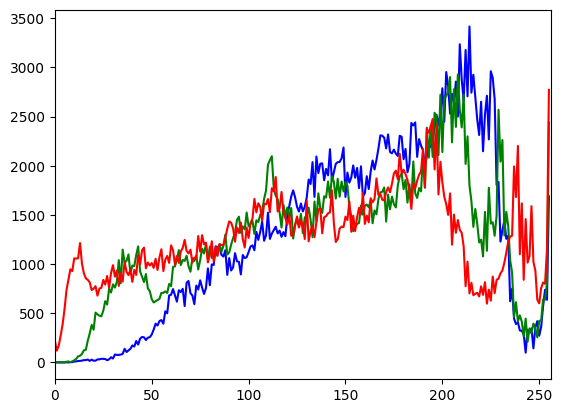

In [6]:
color = ('b','g','r')
for i,col in enumerate(color):
    histr = cv.calcHist([image],[i],None,[256],[0,256])
    plt.plot(histr,color = col)
    plt.xlim([0,256])
plt.show()

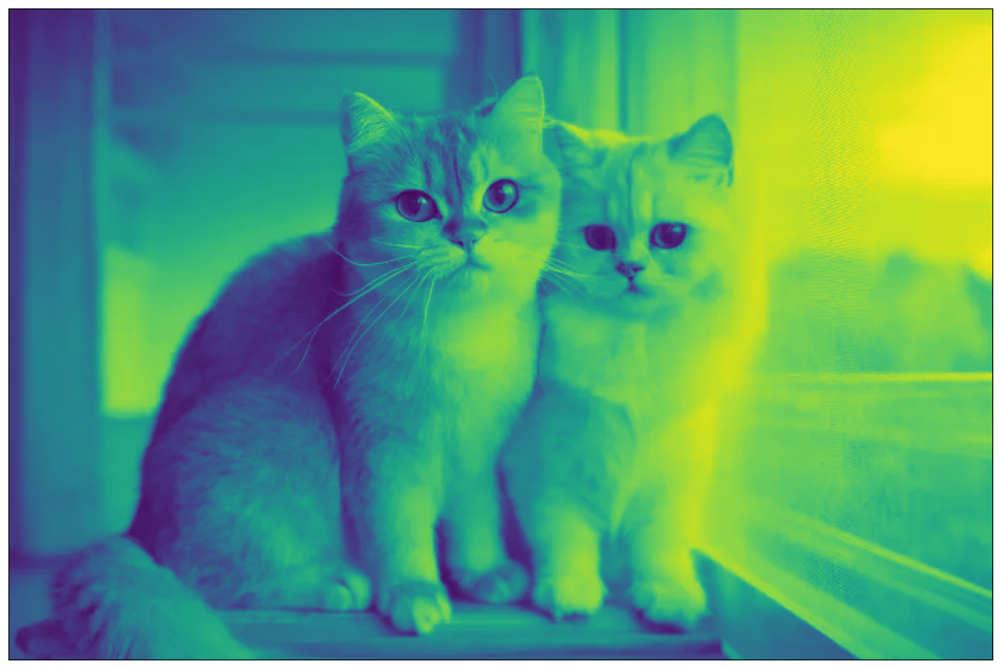

In [7]:
gray_image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
cv_imshow(gray_image)

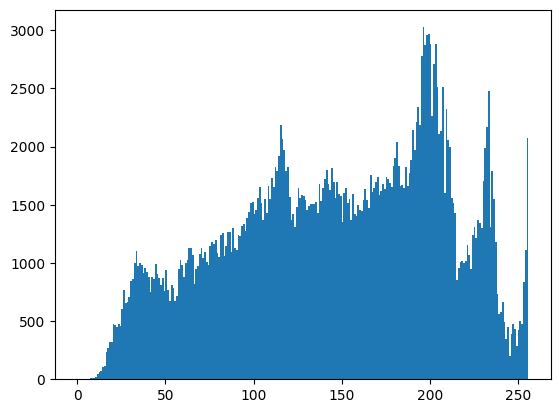

In [8]:
# Plot histogram gambar abu-abu.
# Kita bisa mengamati bahwa frekuensi histori citra mengalami penurunan ~ 1/3 dari histogram citra berwarna
plt.hist(gray_image.ravel(),bins = 256, range = [0, 256])
plt.show()

---
### **TUGAS 2: TAMPILKAN GAMBAR ANDA PADA TUGAS 1 DALAM GRAYSCALE DAN BUAT HISTOGRAMNYA**

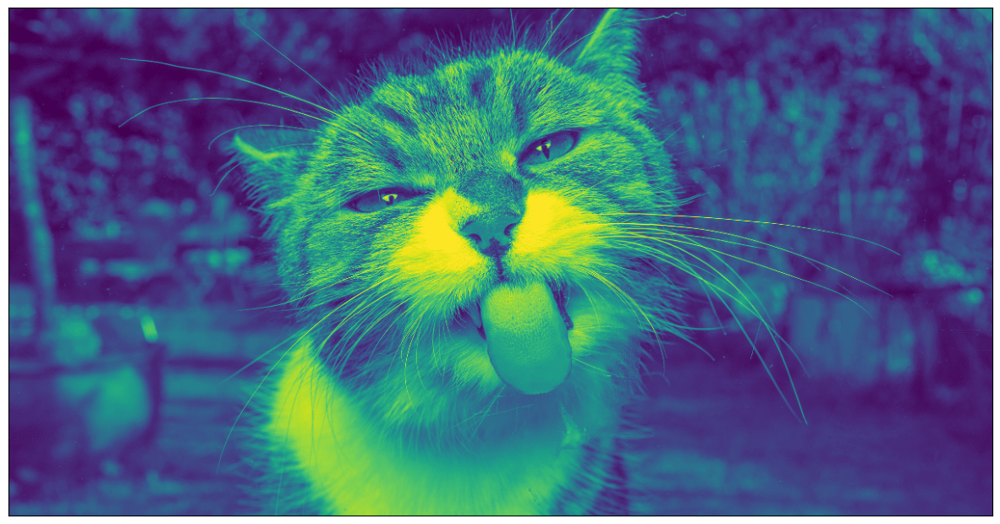

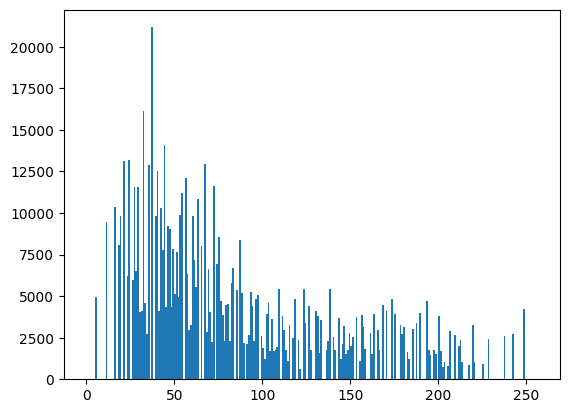

In [9]:
#? TODO 2: SHOW GRAYSCALE IMAGE AND ITS HISTOGRAM

myImg_gray = cv.cvtColor(myImg, cv.COLOR_RGB2GRAY)
cv_imshow(myImg_gray)

plt.hist(myImg_gray.ravel(), bins=256, range=[0, 256])
plt.show()


---

### Temukan kontur gambar dari gambar grayscale.
Metode 1: Gunakan `matplotlib.contour()`

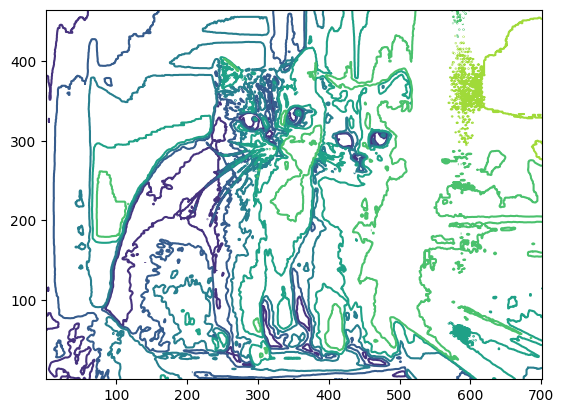

In [10]:
plt.contour(gray_image, origin = "image")

Metode 2: Gunakan library `openCV`

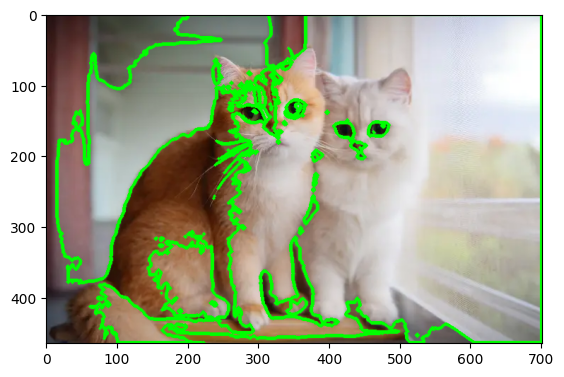

In [11]:
# Atur ambang batas untuk deteksi kontur
ret, thresh = cv.threshold(gray_image,100,200,0)
contours, hierarchy = cv.findContours(thresh, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
cv.drawContours(image, contours, -1, (0, 255, 0), 3)
plt.imshow(image)

---
### **TUGAS 3: TEMUKAN KONTUR GAMBAR ANDA PADA TASK 1**


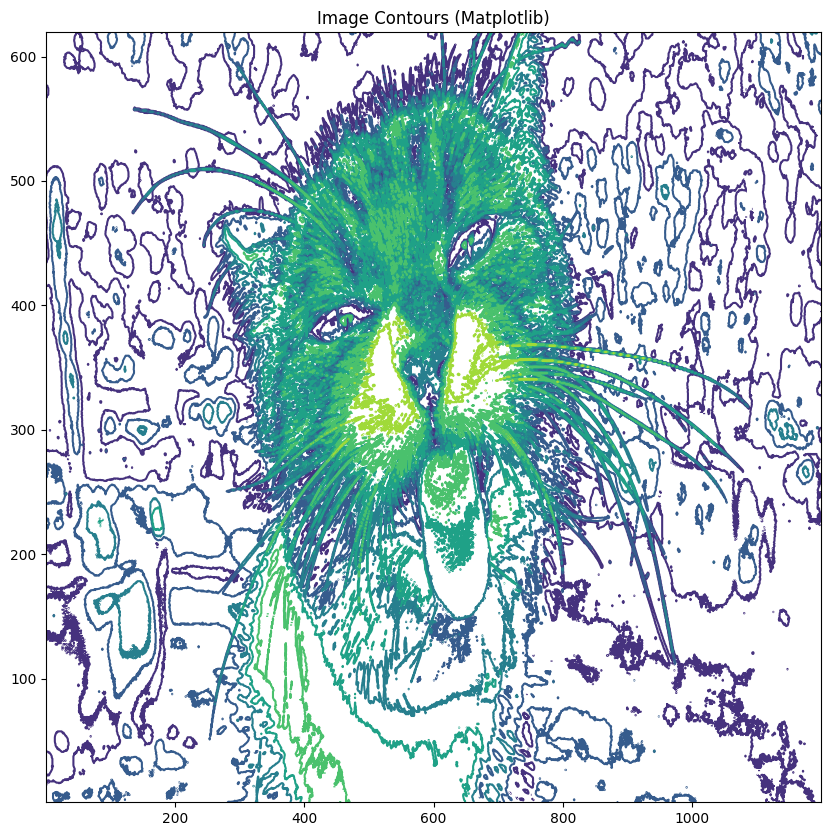

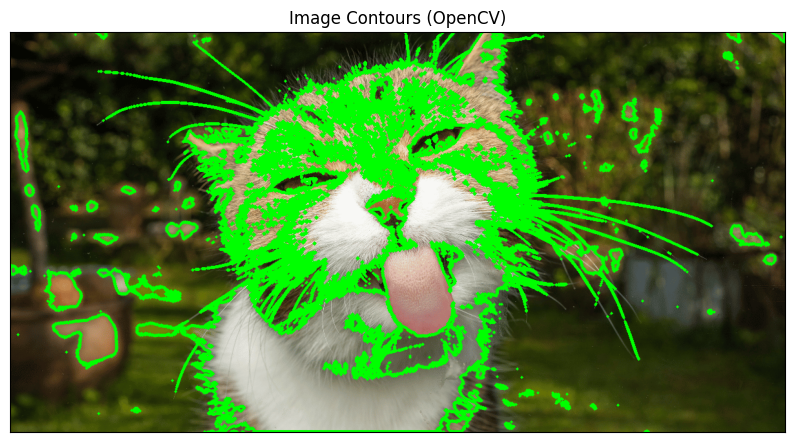

In [12]:
## TODO 3: FIND IMAGE CONTOURS

# Method 1: Using matplotlib.contour()
plt.figure(figsize=(10, 10))
plt.contour(myImg_gray, origin="image")
plt.title("Image Contours (Matplotlib)")
plt.show()

# Method 2: Using OpenCV
ret, thresh = cv.threshold(myImg_gray, 100, 200, 0)
contours, hierarchy = cv.findContours(thresh, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
myImg_contours = myImg.copy()
cv.drawContours(myImg_contours, contours, -1, (0, 255, 0), 3)
plt.figure(figsize=(10, 10))
plt.imshow(myImg_contours)
plt.title("Image Contours (OpenCV)")
plt.xticks([]), plt.yticks([])
plt.show()


---
### 4. Transformasi Grayscale dan Persamaan Histogram

### Grayscale Transformation

Bagian ini memberikan beberapa contoh melakukan transformasi matematis dari gambar grayscale.

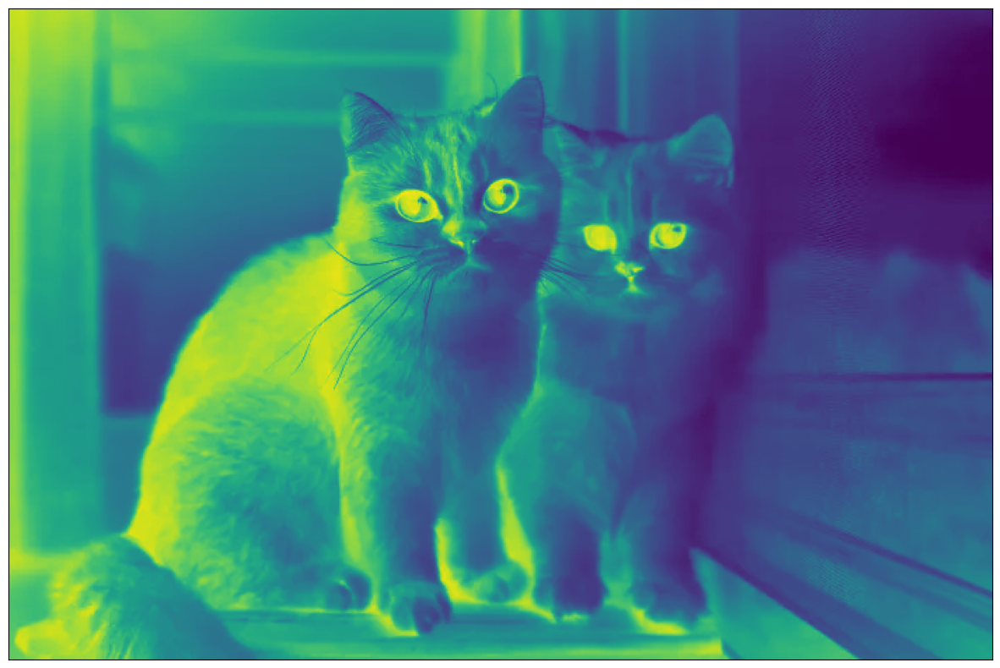

In [13]:
# Ini adalah operasi kebalikan dari gambar grayscale,
# Anda bisa melihat bahwa piksel cerah menjadi gelap, dan piksel gelap menjadi cerah.
im2 = 255 - gray_image
cv_imshow(im2)

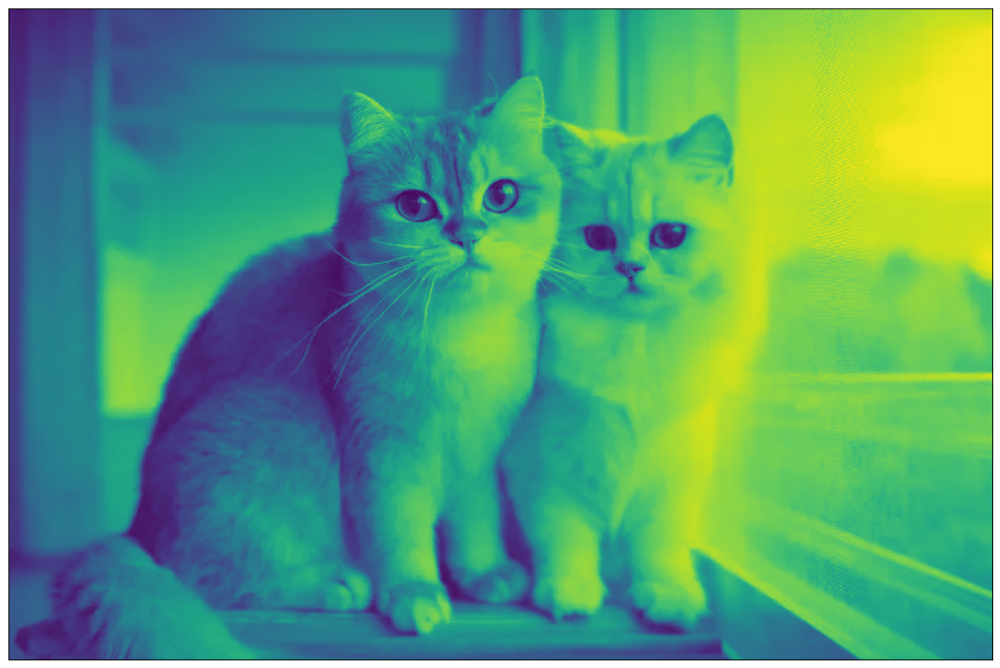

In [14]:
# Transformasi gambar lainnya, setelah menambahkan konstanta,
# semua piksel menjadi lebih cerah dan efek gambar seperti perpeloncoan dihasilkan.
im3 = (100.0/255)*gray_image + 100
cv_imshow(im3)

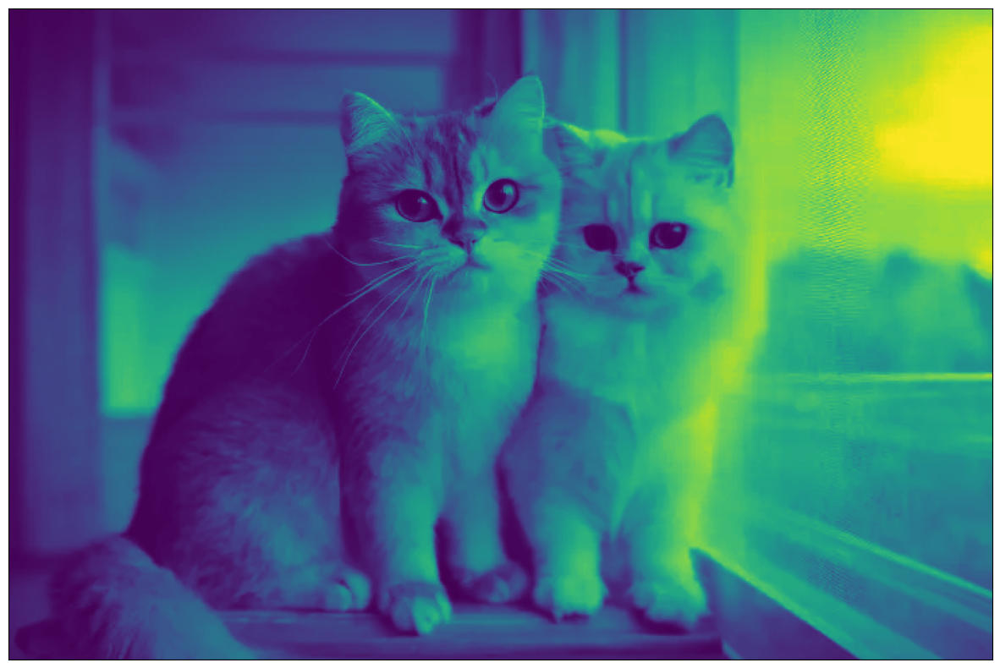

In [15]:
# Tingkat kecerahan gambar abu-abu berkurang setelah langkah ini.
im4 = 255.0*(gray_image/255.0)**2
cv_imshow(im4)

---
### **TUGAS 4: COBALAH BEBERAPA GRAYSCALE TRANSFORMASI PADA GAMBAR ANDA**

Inverted Image:


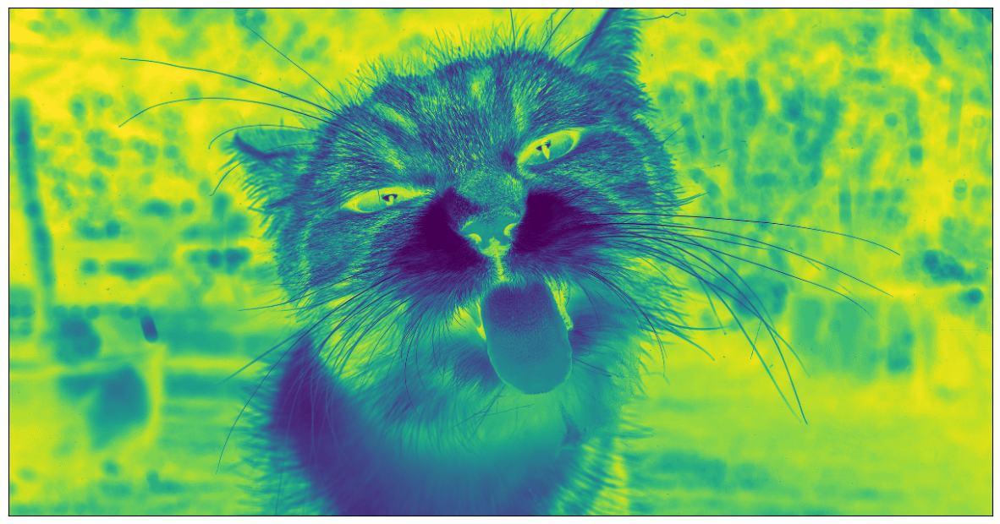

Brightened Image:


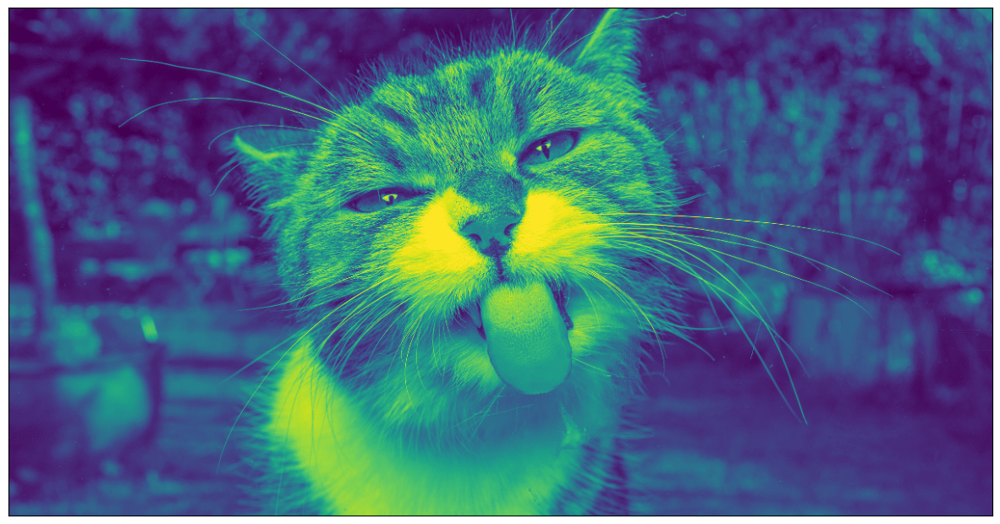

Darkened Image:


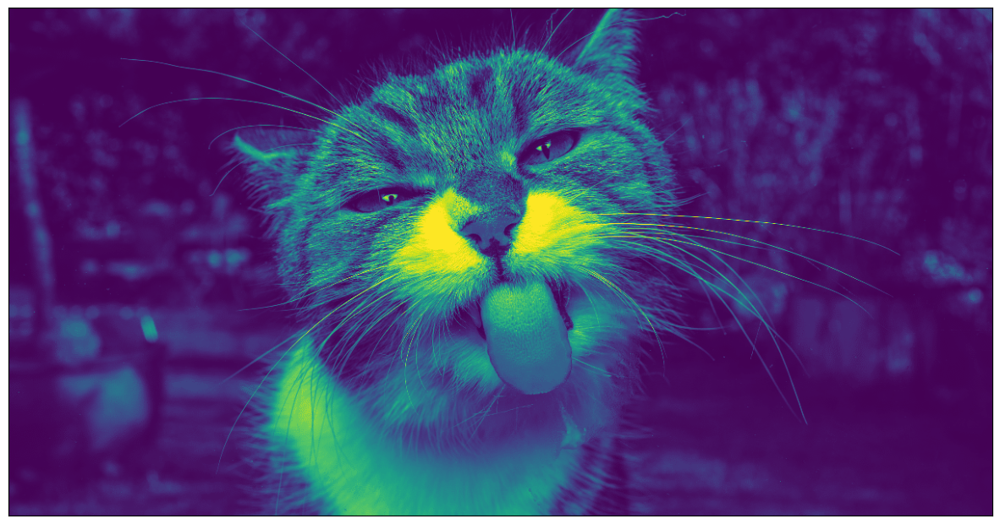

In [16]:
## TODO 4: TRY GRAYSCALE TRANSFORMS

# 1. Invert image
myImg_inv = 255 - myImg_gray
print("Inverted Image:")
cv_imshow(myImg_inv)

# 2. Brighten image
myImg_bright = (100.0/255)*myImg_gray + 100
print("Brightened Image:")
cv_imshow(myImg_bright)

# 3. Darken image
myImg_dark = 255.0*(myImg_gray/255.0)**2
print("Darkened Image:")
cv_imshow(myImg_dark)


---
### Histogram Equalization
Bagian ini mendemonstrasikan pemerataan histogram pada gambar gelap. Transformasi ini meratakan histogram tingkat abu-abu sehingga semua intensitas menjadi seumum mungkin. Fungsi transformasi adalah fungsi distribusi kumulatif (cdf) dari nilai piksel pada citra (dinormalisasi untuk memetakan rentang nilai piksel ke rentang yang diinginkan).

Contoh ini menggunakan gambar 4 (im4).

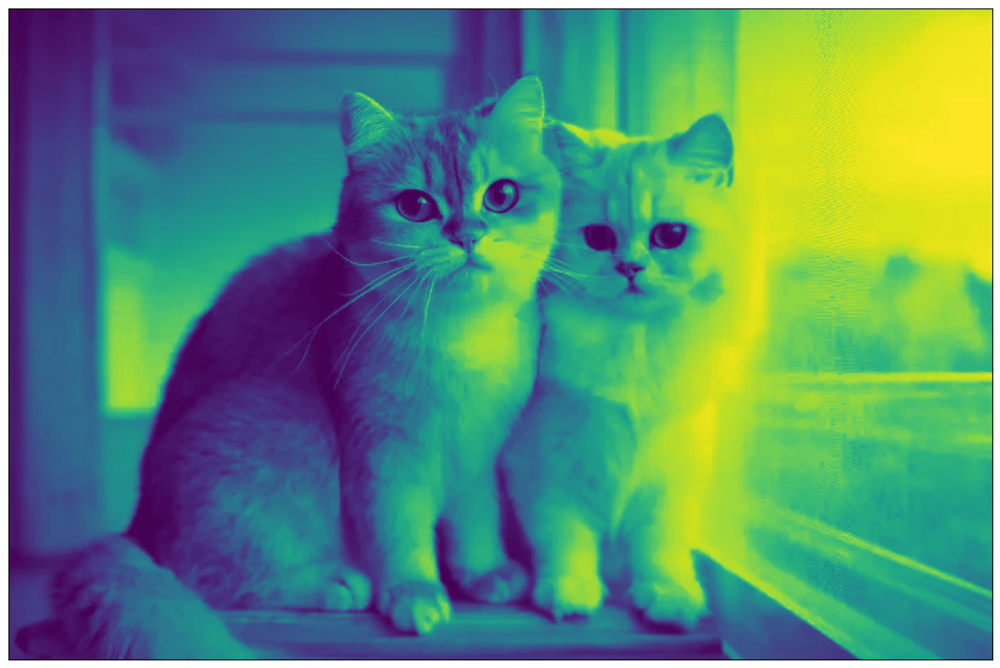

In [17]:
# Fungsi dari histogram equalization
def histeq(im, nbr_bins = 256):
  """ Persamaan histogram dari citra grayscale.  """
  # dapatkan histogram gambar
  imhist, bins = np.histogram(im.flatten(), nbr_bins, [0, 256])
  cdf = imhist.cumsum() # fungsi distribusi kumulatif
  cdf = imhist.max()*cdf/cdf.max()  #normalisasi
  cdf_mask = np.ma.masked_equal(cdf, 0)
  cdf_mask = (cdf_mask - cdf_mask.min())*255/(cdf_mask.max()-cdf_mask.min())
  cdf = np.ma.filled(cdf_mask,0).astype('uint8')
  return cdf[im.astype('uint8')]

# Terapkan fungsi pada gambar gelap Anda untuk meningkatkan kontras
# Anda dapat melihat bahwa kontras latar belakang hitam telah meningkat
im5 = histeq(im4)
cv_imshow(im5)

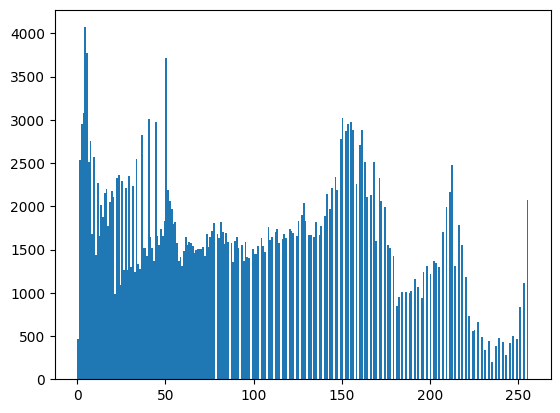

In [18]:
# Ekstra: Coba memvisualisasikan histogram citra setelah pemerataan histogram
# Sebelum pemerataan histogram
plt.hist(im4.ravel(),bins = 256, range = [0, 256])
plt.show()

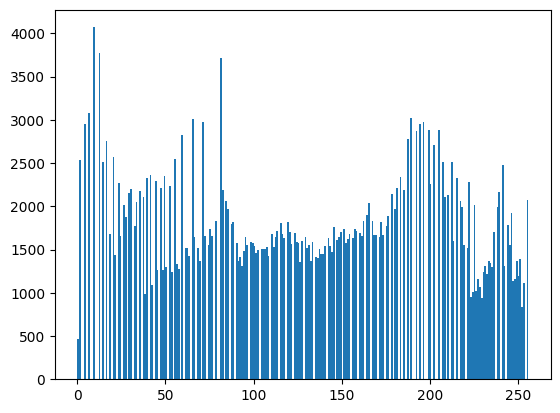

In [19]:
# Setelah pemerataan histogram
plt.hist(im5.ravel(),bins = 256, range = [0, 256])
plt.show()

---
### **TUGAS 5: LAKUKAN PEMERATAAN HISTOGRAM PADA GAMBAR GRAYSCALE ANDA**

Equalized Image:


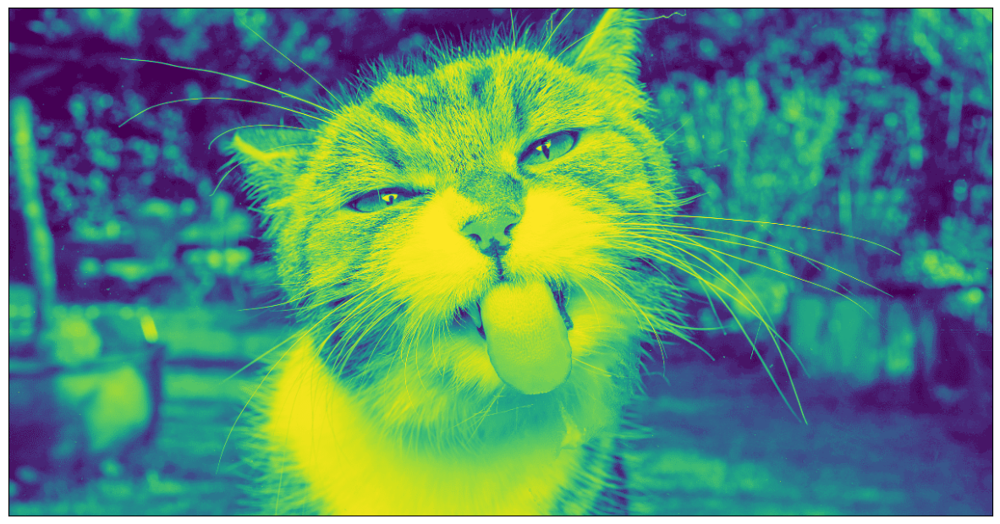

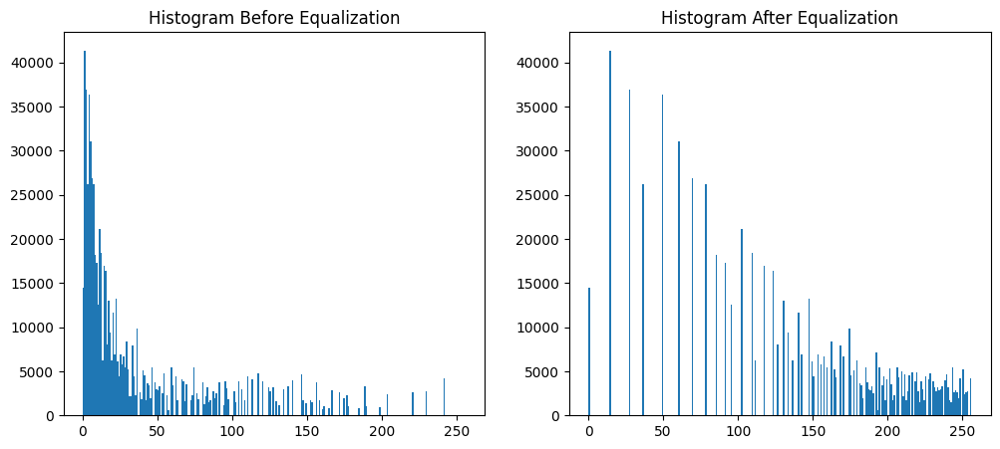

In [20]:
## TODO 5: EQUALIZE GRAYSCALE HISTOGRAM

# Apply histogram equalization on the darkened image
myImg_eq = histeq(myImg_dark)
print("Equalized Image:")
cv_imshow(myImg_eq)

# Plot histogram before and after
plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.hist(myImg_dark.ravel(), bins=256, range=[0, 256])
plt.title("Histogram Before Equalization")

plt.subplot(122)
plt.hist(myImg_eq.ravel(), bins=256, range=[0, 256])
plt.title("Histogram After Equalization")
plt.show()


---
### 5. Transformasi Fourier dari Gambar Abu-abu
Transformasi fourier digunakan untuk mencari domian frekuensi gambar. Anda dapat menganggap gambar sebagai sinyal yang diambil sampelnya dalam dua arah. Jadi mengambil transformasi fourier di kedua arah X dan Y memberi Anda representasi frekuensi gambar. Untuk sinyal sinusoidal, jika amplitudo berubah sangat cepat dalam waktu singkat, dapat dikatakan itu adalah sinyal frekuensi tinggi. Jika bervariasi perlahan, itu adalah sinyal frekuensi rendah. Tepi dan noise adalah konten frekuensi tinggi dalam gambar karena berubah secara drastis dalam gambar.

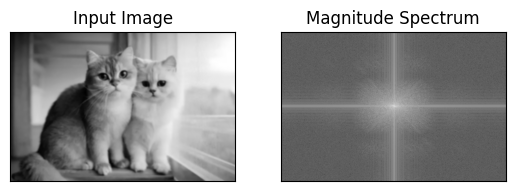

In [21]:
# Buramkan gambar grayscale dengan filter Guassian dengan ukuran kernel 10
imBlur = cv.blur(gray_image,(5,5))

# Ubah gambar menjadi domain frekuensi
f = np.fft.fft2(imBlur)

# Bawa komponen frekuensi-nol ke tengah
fshift = np.fft.fftshift(f)
magnitude_spectrum = 30*np.log(np.abs(fshift))

plt.subplot(121),plt.imshow(imBlur, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

---
### **TUGAS 6: HASILKAN TRANSFORMASI FOURIER DARI GAMBAR GRAYSCALE ANDA**


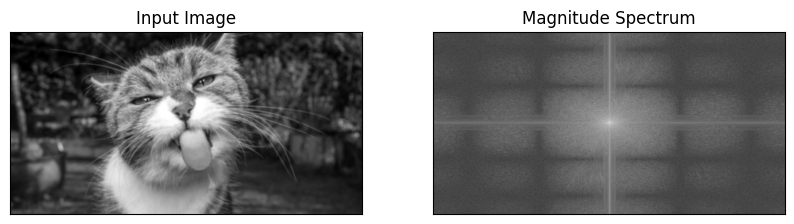

In [22]:
## TODO 6: APPLY FOURIER TRANSFORM

# Blur the image first
myImg_blur = cv.blur(myImg_gray, (5, 5))

# Apply Fourier Transform
f_myImg = np.fft.fft2(myImg_blur)
fshift_myImg = np.fft.fftshift(f_myImg)
magnitude_spectrum_myImg = 30 * np.log(np.abs(fshift_myImg) + 1)

plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(myImg_blur, cmap="gray")
plt.title("Input Image"), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(magnitude_spectrum_myImg, cmap="gray")
plt.title("Magnitude Spectrum"), plt.xticks([]), plt.yticks([])
plt.show()


---
### 6. Menemukan Tepi dengan Highpass Filtering di FFT
Bagian ini mendemonstrasikan melakukan high pass filter untuk menghilangkan komponen frekuensi rendah, sehingga menghasilkan gambar yang tajam yang berisi tepinya.

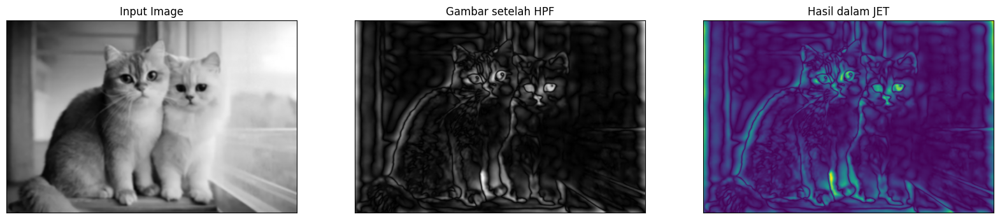

In [23]:
rows, cols = imBlur.shape
crow, ccol = round(rows/2), round(cols/2)

# Hilangkan frekuensi rendah dengan ukuran persegi panjang 10
fshift[crow-10:crow+10, ccol-10:ccol+10] = 0
f_ishift = np.fft.ifftshift(fshift)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

plt.figure(figsize=([20, 20]))
plt.subplot(131),plt.imshow(imBlur, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(img_back, cmap = 'gray')
plt.title('Gambar setelah HPF'), plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(img_back)
plt.title('Hasil dalam JET'), plt.xticks([]), plt.yticks([])
plt.show()

---
### **TUGAS 7: TEMUKAN TEPI DENGAN HIGHPASS FILTERING**


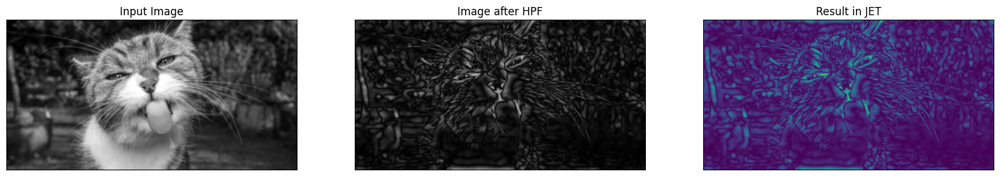

In [24]:
## TODO 7: DETECT EDGES

rows, cols = myImg_blur.shape
crow, ccol = round(rows/2), round(cols/2)

# Remove low frequencies (Highpass Filter)
fshift_myImg[crow-10:crow+10, ccol-10:ccol+10] = 0
f_ishift_myImg = np.fft.ifftshift(fshift_myImg)
myImg_back = np.fft.ifft2(f_ishift_myImg)
myImg_back = np.abs(myImg_back)

plt.figure(figsize=([20, 10]))
plt.subplot(131), plt.imshow(myImg_blur, cmap="gray")
plt.title("Input Image"), plt.xticks([]), plt.yticks([])
plt.subplot(132), plt.imshow(myImg_back, cmap="gray")
plt.title("Image after HPF"), plt.xticks([]), plt.yticks([])
plt.subplot(133), plt.imshow(myImg_back)
plt.title("Result in JET"), plt.xticks([]), plt.yticks([])
plt.show()


---
### **TUGAS 8: BERIKAN KESIMPULAN DARI TAHAPAN TAHAPAN DI ATAS**

**Kesimpulan:**
Berdasarkan seluruh tahapan praktikum pengolahan citra yang telah dilakukan, dapat ditarik beberapa kesimpulan sebagai berikut:

1. **Konversi Grayscale dan Analisis Histogram:** Citra berwarna dapat disederhanakan menjadi grayscale untuk memudahkan pemrosesan. Histogram sangat berguna untuk memvisualisasikan persebaran nilai intensitas piksel, di mana kita dapat mengetahui apakah suatu citra cenderung gelap, terang, atau memiliki kontras yang baik.
2. **Ekstraksi Kontur (Deteksi Bentuk):** Dengan menerapkan *thresholding* untuk memisahkan objek dari latar belakang, kita dapat mendeteksi batas-batas tepi luar objek (kontur) menggunakan *OpenCV* maupun *Matplotlib*. Ini adalah teknik dasar dalam segmentasi objek.
3. **Transformasi Grayscale:** Tingkat kecerahan citra dapat dimanipulasi dengan operasi matematika sederhana, seperti inversi (mengubah gelap menjadi terang dan sebaliknya), penambahan nilai konstan (*brightening*), atau operasi pangkat (*darkening*).
4. **Pemerataan Histogram (*Histogram Equalization*):** Teknik ini efektif untuk memperbaiki kontras citra secara global. Dengan meratakan fungsi distribusi kumulatif intensitas piksel, citra yang awalnya terlalu gelap (kurang kontras) dapat diubah menjadi lebih jelas dan detailnya lebih mudah dilihat.
5. **Transformasi Fourier dan *Highpass Filtering*:** Transformasi Fourier membawa citra dari domain spasial ke domain frekuensi. Komponen frekuensi tinggi merepresentasikan perubahan intensitas yang drastis (yaitu tepi atau batas objek). Dengan menerapkan *Highpass Filter* (HPF) untuk memblokir frekuensi rendah di tengah spektrum dan melakukan *Inverse Fourier Transform* (IFFT), kita dapat secara efektif mengekstrak garis tepi (edges) dari citra tersebut.


---

<div class="alert alert-warning">
<strong>Perhatian!</strong> Berikut merupakan cara konversi File IPYNB menjadi File PDF untuk melakukan pengumpulan tugas di Virtual Class.
    <a href="https://youtu.be/qXELXtnAK7c">Video konversi</a>.
    </div>


---


Copyright © Pengelola MK Praktikum Unggulan (Praktikum DGX), Universitas Gunadarma


https://www.praktikum-hpc.gunadarma.ac.id/